In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("archery_shot_dataset.csv")

In [10]:
df.head()

,archer_id,experience_years,skill_level,shot_number,time_step,shooting_phase,heart_rate,stress_level,aim_time_sec,movement_x,...,movement_z,movement_magnitude,shoulder_angle,elbow_angle,spine_tilt,posture_error,wind_speed,bow_angle_error,score,performance_class
0,1,1,46,1,8,Release,75.269278,0.186181,3.761261,-0.003694,...,0.008278,0.028234,88.606113,160.081500,5.388219,0.037565,3.705745,1.491370,6.641241,Poor
1,1,1,46,2,8,Release,74.550723,0.202475,3.752460,0.026346,...,-0.002684,0.027871,89.902207,157.965257,5.373855,0.034573,2.981119,0.526559,6.438362,Poor
2,1,1,46,3,8,Release,74.705274,0.226215,4.019004,-0.021933,...,0.005935,0.024240,95.356244,156.872669,4.740733,0.093463,4.350078,1.960565,6.236345,Poor
3,1,1,46,4,8,Release,74.735885,0.208156,3.813219,-0.013667,...,0.000562,0.026656,86.326425,157.915949,5.263959,0.068507,2.027914,1.851232,6.669358,Poor
4,1,1,46,5,8,Release,75.371013,0.216505,3.937522,0.036478,...,0.023516,0.043430,90.310580,157.350703,4.420597,0.052198,3.225472,-0.548190,6.072229,Poor


In [11]:
df.describe()

,archer_id,experience_years,skill_level,shot_number,time_step,heart_rate,stress_level,aim_time_sec,movement_x,movement_y,movement_z,movement_magnitude,shoulder_angle,elbow_angle,spine_tilt,posture_error,wind_speed,bow_angle_error,score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.500000,6.52000,70.980000,100.500000,8.0,72.559632,0.234407,3.926170,0.002565,0.000105,-0.000187,0.024964,89.940594,159.904708,4.681872,0.071383,2.776638,0.884509,9.077339
std,14.431591,3.32426,12.862198,57.737192,0.0,6.185077,0.054621,0.153980,0.017939,0.017164,0.013137,0.013129,2.333056,2.429530,0.800115,0.033561,0.982699,0.962667,1.391525
min,1.000000,1.00000,44.000000,1.000000,8.0,57.090059,0.061942,3.495931,-0.081044,-0.081098,-0.062487,0.000485,78.785512,150.466312,1.932932,0.003512,0.000000,-2.869767,2.754030
25%,13.000000,4.00000,61.000000,50.750000,8.0,66.976958,0.194687,3.812505,-0.008417,-0.010523,-0.008120,0.015353,88.416136,158.332116,4.122993,0.046641,2.097523,0.238059,8.367992
50%,25.500000,6.50000,70.500000,100.500000,8.0,72.833748,0.230822,3.916592,0.002315,-0.000081,0.000004,0.022603,89.922292,159.871205,4.615887,0.067485,2.764809,0.877655,10.000000
75%,38.000000,10.00000,81.000000,150.250000,8.0,77.559133,0.272630,4.029081,0.013463,0.010568,0.007825,0.032154,91.468063,161.468343,5.174944,0.091683,3.455500,1.513391,10.000000
max,50.000000,11.00000,93.000000,200.000000,8.0,89.830800,0.406384,4.443962,0.091525,0.083726,0.069490,0.102845,99.303976,169.409233,8.337466,0.231497,6.244906,4.527134,10.000000


In [12]:
print(df["archer_id"].nunique())

50


In [18]:
nan_counts = df.isna().sum()

print(f"Total NaN values: {df.isna().sum().sum()}")
print(f"By column: \n{nan_counts}")


Total NaN values: 0
By column: 
archer_id             0
experience_years      0
skill_level           0
shot_number           0
time_step             0
shooting_phase        0
heart_rate            0
stress_level          0
aim_time_sec          0
movement_x            0
movement_y            0
movement_z            0
movement_magnitude    0
shoulder_angle        0
elbow_angle           0
spine_tilt            0
posture_error         0
wind_speed            0
bow_angle_error       0
score                 0
performance_class     0
dtype: int64


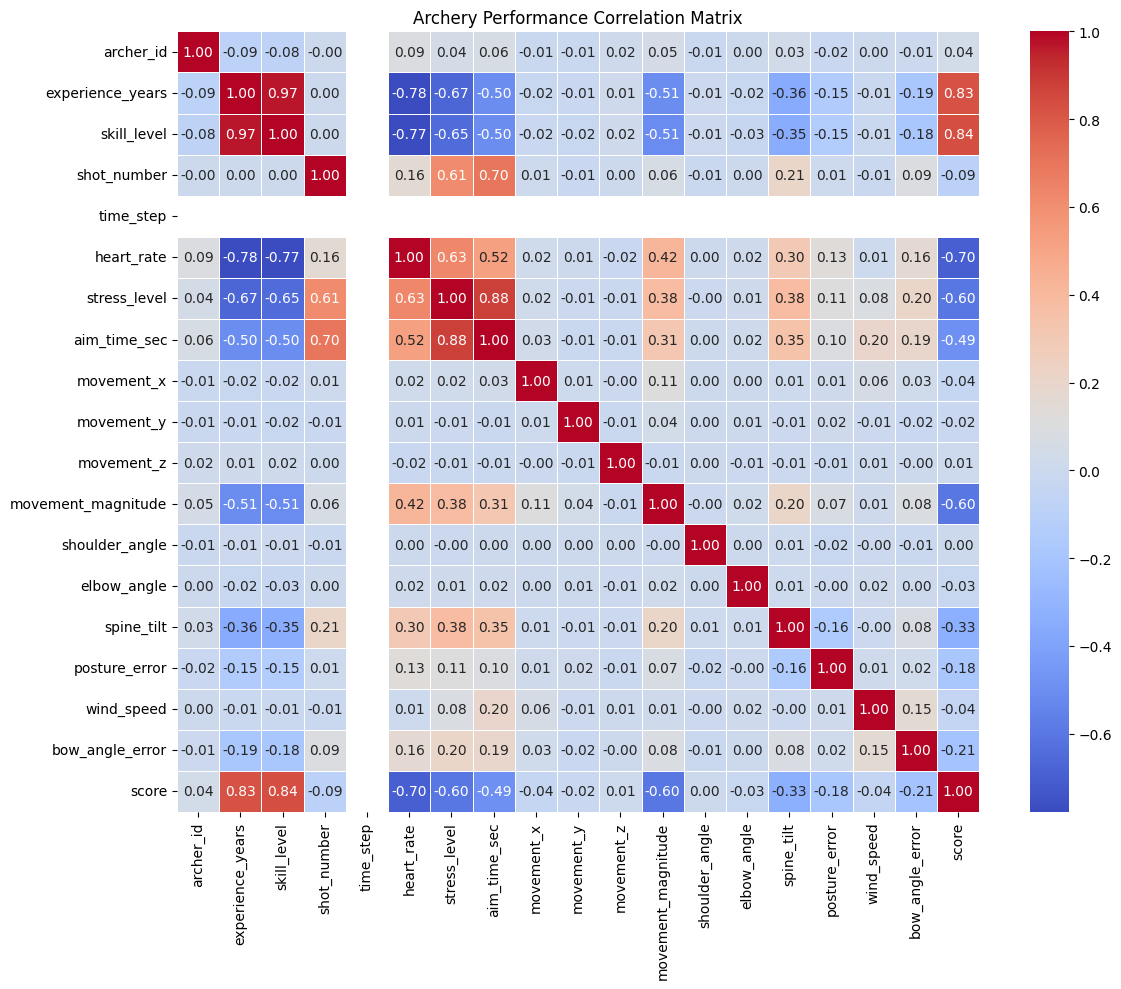

In [212]:
numerical_df = df.select_dtypes(include=["float64", "int64"])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Archery Performance Correlation Matrix")

plt.tight_layout()
plt.savefig("overview_correlation_matrix.png")

## Pre-processing

In [28]:
from matplotlib.colors import LinearSegmentedColormap

target_colours = ["#ffffff", "#000000", "#05a1ee", "#fb4338", "#f1cc00"]
archery_cmap = LinearSegmentedColormap.from_list("ArcheryTarget", target_colours, N=10)

In [185]:

# Z-Axis Sorted Dataframes
df_sorted_by_score = df.sort_values("score")
df_sorted_by_windspeed = df.sort_values("wind_speed")
df_sorted_by_movementmagnitude = df.sort_values("movement_magnitude")

# 4.1 Biometric-Kinematics Relation 

Physiological data like heart rate is used as an isolated variable used only for dramatic effect during the broadcast, with a failure to relate [1] this data to physical state at the moment of release. Using the heart_rate and stress_level variables, I can map an archers physiological state with their physical output state. This provides a snapshot, allowing the identification of correlations, for example demonstrating that a specific posture_error was coincident with a higher stress_level or heart_rate value.


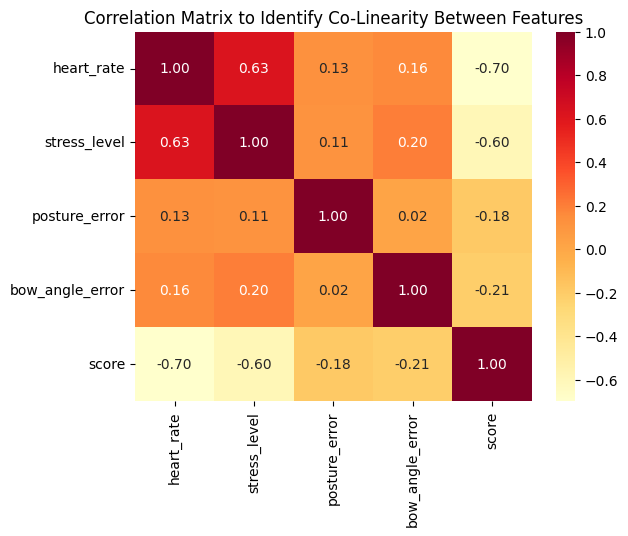

In [169]:
biometric_columns = [ "heart_rate", "stress_level", "posture_error", "bow_angle_error", "score" ]

correlation_matrix = df[biometric_columns].corr()
plt.title("Correlation Matrix to Identify Co-Linearity Between Features")
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrRd", fmt=".2f")
plt.savefig("graphs/4-1-correlation_matrix.png", dpi=300)


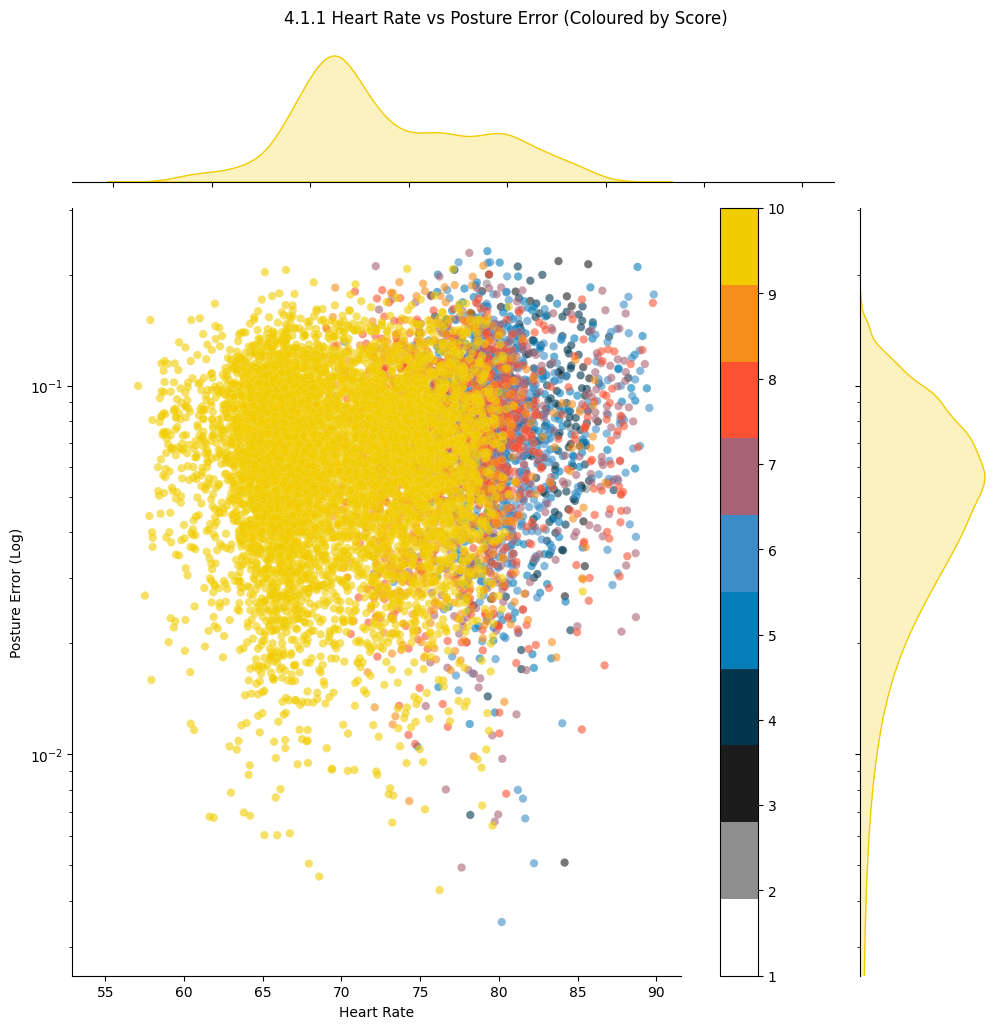

In [170]:
# plot = sns.JointGrid(data=df, x="stress_level", y="posture_error")
# plot.plot_joint(sns.scatterplot, hue=df["score"], palette=archery_cmap, alpha=0.8, linewidth=0.1)
# plot.plot_marginals(sns.kdeplot, fill=True, color=target_colours[4])

plot = sns.jointplot(
    data=df_sorted_by_score, x="heart_rate", y="posture_error",
    hue="score", palette=archery_cmap, alpha=0.6, linewidth=0.1,
    marginal_kws={ "fill": True, "color": target_colours[4] },
    height=10
)

plot.ax_joint.set_yscale("log")
plot.ax_joint.set_ylim(bottom=10**-2.6)

plot.set_axis_labels("Heart Rate", "Posture Error (Log)")
plot.ax_joint.legend_.remove()

sm = plt.cm.ScalarMappable(cmap=archery_cmap, norm=plt.Normalize(1, 10))
cbar = plot.fig.colorbar(sm, ax=[plot.ax_joint], location="right", pad=0.05)

plot.fig.suptitle("4.1.1 Heart Rate vs Posture Error (Coloured by Score)", y=1.025)


plt.savefig("graphs/4-1-1-BiometricKinematicRelation.png", dpi=300)

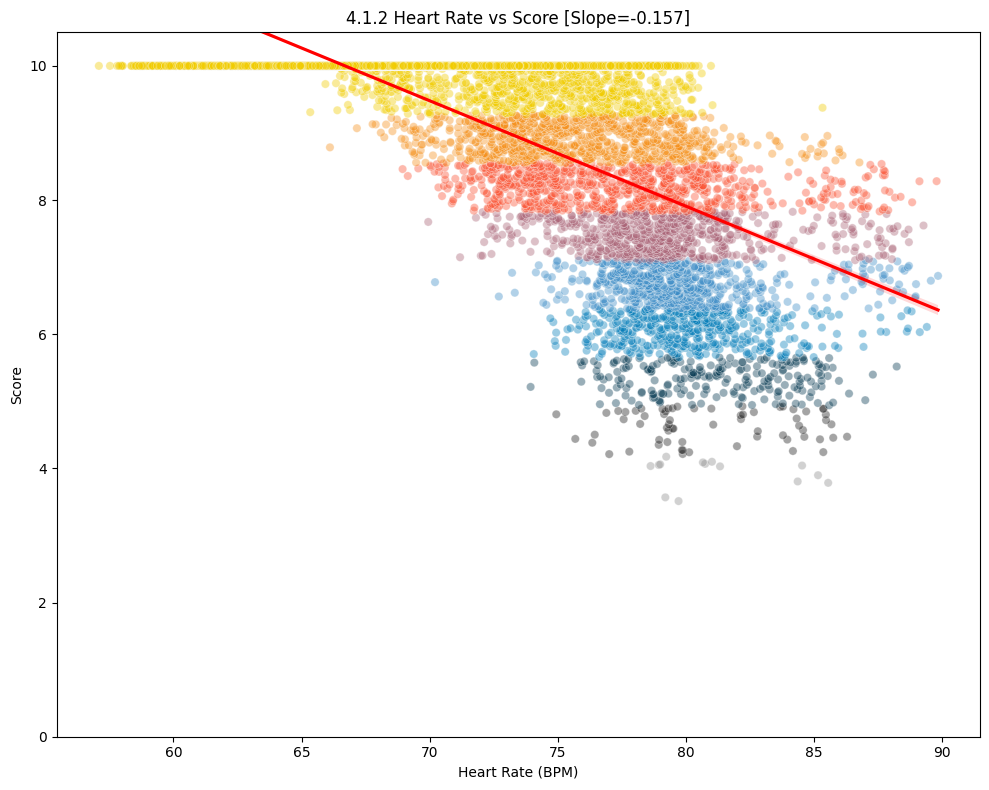

In [171]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_sorted_by_score,
    x="heart_rate", y="score", 
    hue="score", palette=archery_cmap, alpha=0.4, 
    ax=ax
)
sns.regplot(
    data=df_sorted_by_score,
    x="heart_rate", y="score",
    scatter=False, color="red",
    ax=ax
)

slope, intercept = np.polyfit(df["heart_rate"], df["score"], 1)

ax.set_title(f"4.1.2 Heart Rate vs Score [Slope={slope:.3f}]")
ax.set_xlabel("Heart Rate (BPM)")
ax.set_ylabel("Score")
ax.set_ylim(0, 10.5)
ax.get_legend().remove()

plt.tight_layout()
plt.savefig("graphs/4-1-2-BiometricScoreRelation.png", dpi=300)

# 4.2 Environmental-Error Relation

Arrow trajectory “tracers” render historical data, showing where an arrow was located but not why it followed that path. I could map wind_speed against bow_angle_error and posture_error to visualise a predicted “impact zone”, providing “Detail on Demand” [1]. This could be used to compare the impact on score from external environmental factors with the impact derived from the archers physical form.


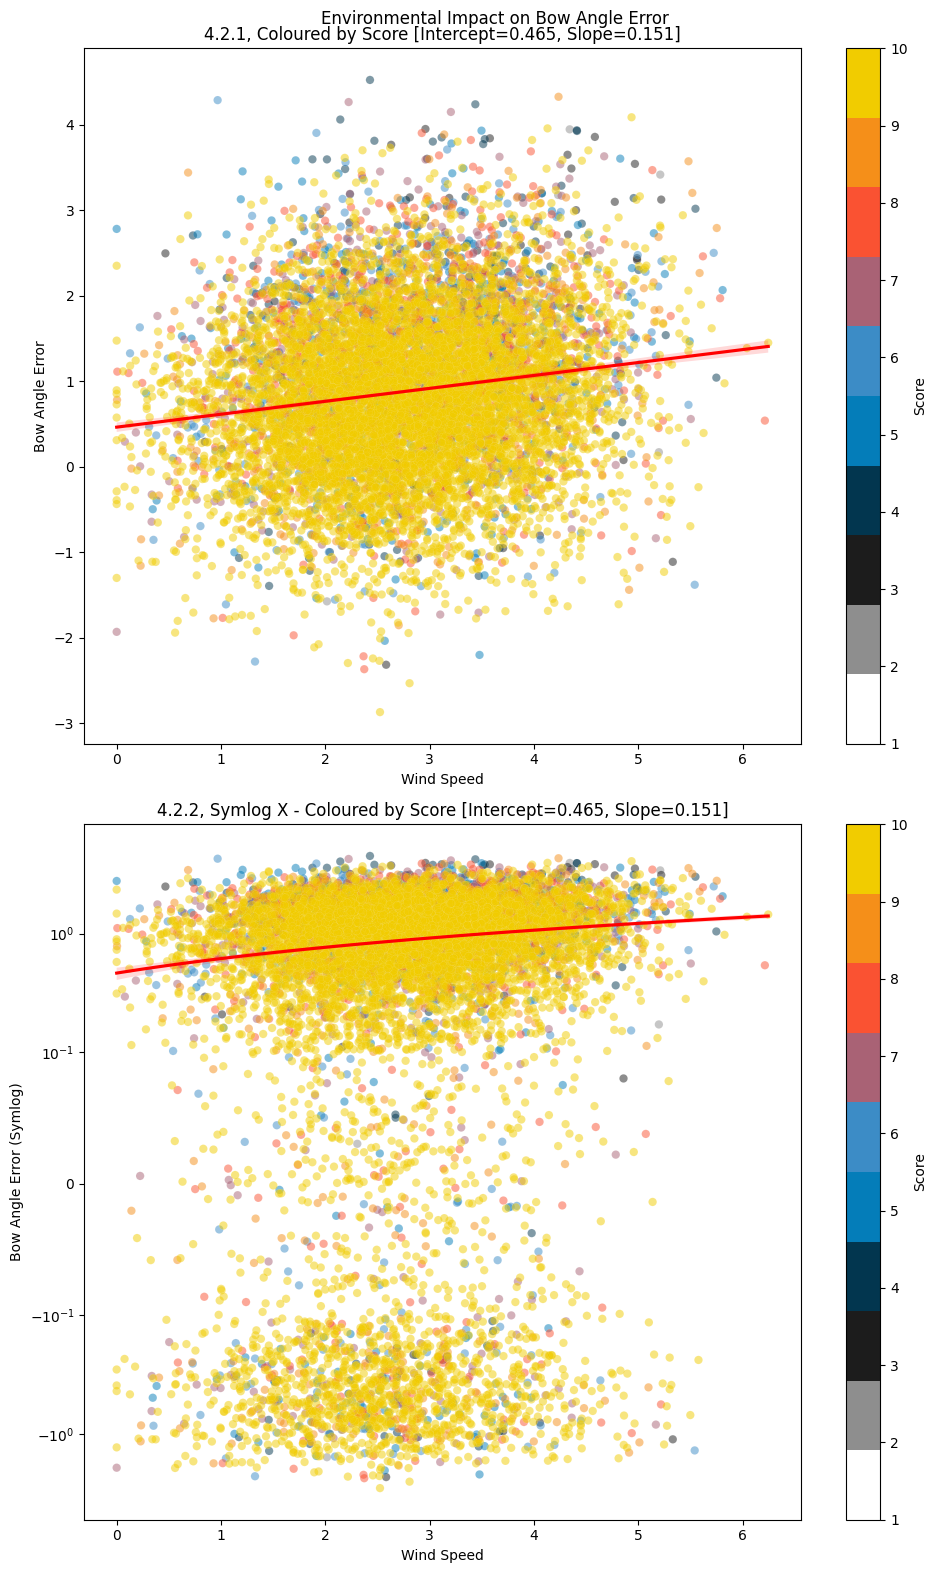

In [175]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# 4.2.1
sns.scatterplot(
    data=df_sorted_by_score, x="wind_speed", y="bow_angle_error",
    hue="score", palette=archery_cmap, alpha=0.5, linewidth=0.1,
    ax=ax1
)
sns.regplot(
    data=df, x="wind_speed", y="bow_angle_error",
    scatter=False, color="red",
    ax=ax1
)

slope, intercept = np.polyfit(df["wind_speed"], df["bow_angle_error"], 1)

ax1.set_title(f"4.2.1, Coloured by Score [Intercept={intercept:.3f}, Slope={slope:.3f}]")
ax1.set_xlabel("Wind Speed")
ax1.set_ylabel("Bow Angle Error")
ax1.get_legend().remove()


# 4.2.2 
sns.scatterplot(
    data=df_sorted_by_score, x="wind_speed", y="bow_angle_error",
    hue="score", palette=archery_cmap, alpha=0.5, linewidth=0.1,
    ax=ax2
)
sns.regplot(
    data=df, x="wind_speed", y="bow_angle_error",
    scatter=False, color="red",
    ax=ax2
)

slope, intercept = np.polyfit(df["wind_speed"], df["bow_angle_error"], 1)

ax2.set_title(f"4.2.2, Symlog X - Coloured by Score [Intercept={intercept:.3f}, Slope={slope:.3f}]")
ax2.set_xlabel("Wind Speed")
ax2.set_ylabel("Bow Angle Error (Symlog)")
ax2.get_legend().remove()
ax2.set_yscale("symlog", linthresh=0.1)

sm1 = plt.cm.ScalarMappable(cmap=archery_cmap, norm=plt.Normalize(1, 10))
cbar_ax1 = plt.colorbar(sm1, ax=ax1)
cbar_ax1.set_label("Score")

cbar_ax2 = plt.colorbar(sm1, ax=ax2)
cbar_ax2.set_label("Score")

fig.suptitle("Environmental Impact on Bow Angle Error")
plt.tight_layout()
plt.savefig("graphs/4-2-1-EnviromentalImpactOnBowAngleError.png", dpi=300)

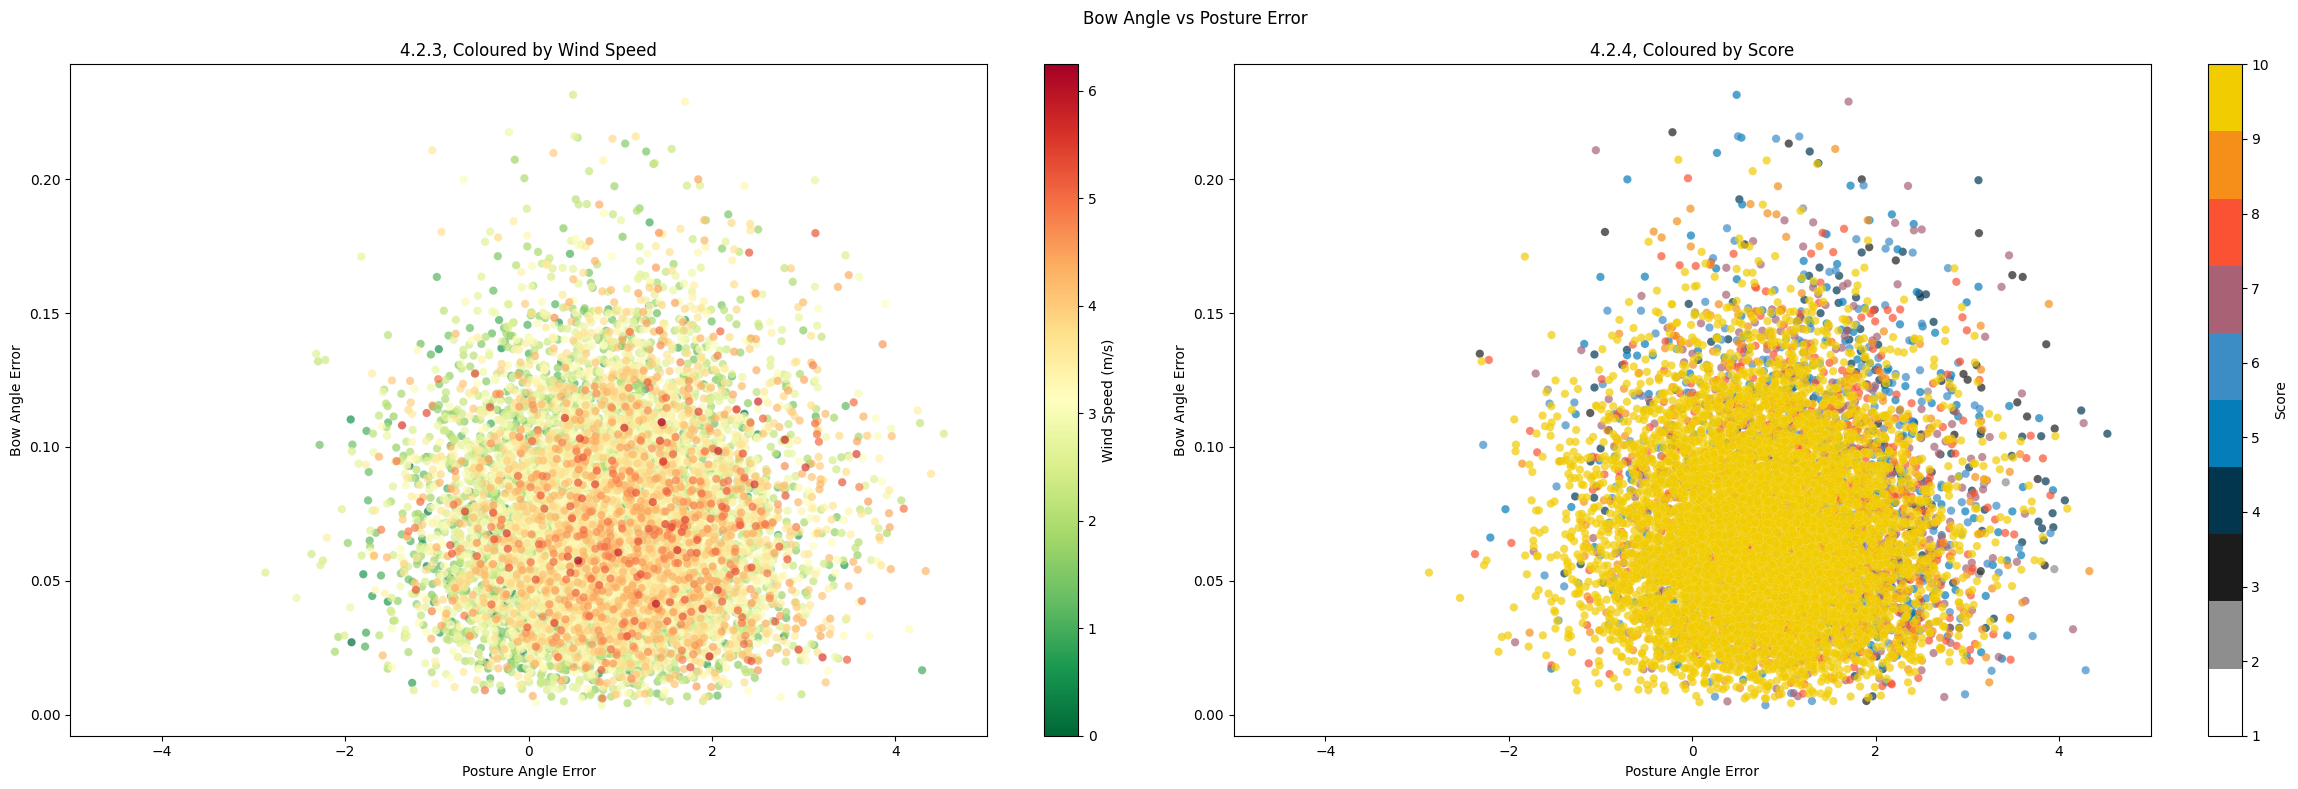

In [174]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# 4.2.2
sns.scatterplot(
    data=df_sorted_by_windspeed, x="bow_angle_error", y="posture_error",
    hue="wind_speed", palette="RdYlGn_r", alpha=0.7, linewidth=0.1,
    ax=ax1
)

ax1.set_xlim(-5, 5)
ax1.set_title("4.2.3, Coloured by Wind Speed")
ax1.set_xlabel("Posture Angle Error")
ax1.set_ylabel("Bow Angle Error")
ax1.get_legend().remove()

# 4.2.3
sns.scatterplot(
    data=df_sorted_by_score, x="bow_angle_error", y="posture_error",
    hue="score", palette=archery_cmap, alpha=0.7, linewidth=0.1,
    ax=ax2
)

ax2.set_xlim(-5, 5)
ax2.set_title("4.2.4, Coloured by Score")
ax2.set_xlabel("Posture Angle Error")
ax2.set_ylabel("Bow Angle Error")
ax2.get_legend().remove()

# Colorbars
wind_min, wind_max = df["wind_speed"].min(), df["wind_speed"].max()
sm1 = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(wind_min, wind_max))
cbar_ax2 = fig.colorbar(sm1, ax=ax1)
cbar_ax2.set_label("Wind Speed (m/s)")

sm1 = plt.cm.ScalarMappable(cmap=archery_cmap, norm=plt.Normalize(1, 10))
cbar_ax2 = plt.colorbar(sm1, ax=ax2)
cbar_ax2.set_label("Score")

fig.suptitle("Bow Angle vs Posture Error")
plt.tight_layout()
plt.savefig("graphs/4-2-3-BowAnglePostureError.png", dpi=300)


# 4.3 Fatigue Stability Plot

A scatter plot with regression line/curve mapping the aim_time_sec feature against score, colour mapped with movement_magnitude bins. This would allow the archer to visualise whether they are “overholding” during their aiming phase. This provides an overview of all shots, but the archer can focus on a single data point to “zoom and filter”, receiving additional “Detail on demand”.


In [199]:
df["stability_bins"] = pd.qcut(df["movement_magnitude"], 6, labels=list(range(6, 0, -1)))
stability_palette = sns.color_palette("RdYlGn_r", n_colors=6)

C:\Users\richa\AppData\Local\Temp\ipykernel_43524\1194273213.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(


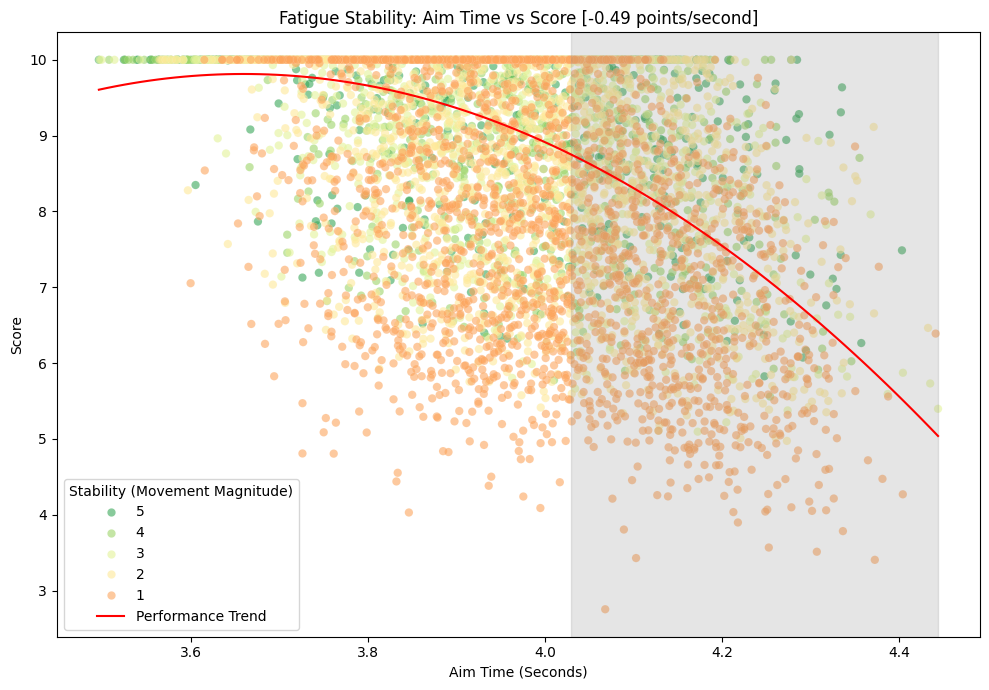

In [210]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df_sorted_by_movementmagnitude,
    x="aim_time_sec", y="score",
    hue="stability_bins", palette=stability_palette, alpha=0.6, linewidth=0.1,
    ax=ax
)

weights = np.polyfit(df["aim_time_sec"], df["score"], 2)
polynomial = np.poly1d(weights)
x_range = np.linspace(df["aim_time_sec"].min(), df["aim_time_sec"].max(), 100)
y_range = polynomial(x_range)
ax.plot(x_range, y_range, color="red", label="Performance Trend")

correlation = df["aim_time_sec"].corr(df["score"])

ax.set_title(f"Fatigue Stability: Aim Time vs Score [{correlation:.2f} points/second]")
ax.set_xlabel("Aim Time (Seconds)")
ax.set_ylabel("Score")

ax.axvspan(df["aim_time_sec"].quantile(0.75), df["aim_time_sec"].max(), color="grey", alpha=0.2)

ax.legend(title="Stability (Movement Magnitude)", loc="lower left")

plt.tight_layout()
plt.savefig("graphs/4-3-1-FatigueStabilityPlot.png", dpi=300)